# 1

In [1]:
import numpy as np
import cv2

from ultralytics.utils import IterableSimpleNamespace
from ultralytics.data.dataset import YOLODataset

import matplotlib.pyplot as plt

INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.5 (you have 1.4.11). Upgrade using: pip install --upgrade albumentations


In [ ]:
# create dataset config
default_cfg = IterableSimpleNamespace(task='detect', bgr=0., mode='val', copy_paste_mode='flip', model=None, data=None, epochs=100, patience=50, batch=16, imgsz=1024, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=True, optimizer='auto', verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split='val', save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, line_width=None, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, format='torchscript', keras=False, optimize=False, int8=False, dynamic=False, simplify=False, opset=None, workspace=4, nms=False, lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=7.5, cls=0.5, dfl=1.5, pose=12.0, kobj=1.0, label_smoothing=0.0, nbs=64, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, degrees=0.0, translate=0.1, scale=0.5, shear=0.0, perspective=0.0, flipud=0.0, fliplr=0.5, mosaic=1.0, mixup=0.0, copy_paste=0.0, cfg=None, tracker='botsort.yaml')

In [28]:
my_dataset = YOLODataset(
    data={'names': ['zadir', 'scratch', 'oxidation', 'nakol', 'plena', 'hole', 'omednenie', 'vmyatina', 'rakovina', 'dirt']},
    img_path=r"C:\Users\User\Desktop\Projects\actual\ultralytics_custom_augs\data_test", #"../YOLO8_DATASET/"
    imgsz=1024,
    hyp=default_cfg,
    batch_size=1
)

Scanning C:\Users\User\Desktop\Projects\actual\ultralytics_custom_augs\data_test\labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


In [57]:
my_dataset = YOLODataset(
    data={'names': ['zadir', 'scratch', 'oxidation', 'nakol', 'plena', 'hole', 'omednenie', 'vmyatina', 'rakovina', 'dirt']},
    img_path=r"C:\Users\User\Desktop\Projects\actual\ultralytics_custom_augs\data_test",
    imgsz=1024,
    hyp=default_cfg,
    batch_size=1
)

Scanning C:\Users\User\Desktop\Projects\actual\ultralytics_custom_augs\data_test\labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


In [50]:
def yolo_to_opencv_bbox(yolo_bboxes, image_width=1024, image_height=1024):
    opencv_bboxes = []
    
    for bbox in yolo_bboxes:
        # print(bbox)
        x_center, y_center, width, height = bbox
        
        # Преобразование нормализованных координат в координаты пикселей
        x_center *= image_width
        y_center *= image_height
        width *= image_width
        height *= image_height
        
        # Определение координат верхнего левого угла
        x_min = int(x_center - width / 2)
        y_min = int(y_center - height / 2)
        x_max = int(x_min + width)
        y_max = int(y_min + height)
        opencv_bboxes.append([x_min, y_min, x_max, y_max])
        
    return opencv_bboxes

img shape: (1024, 956, 3), h, w(1024, 956)
img shape: (1024, 956, 3), h, w(1024, 956)
img shape: (1024, 956, 3), h, w(1024, 956)
img shape: (1024, 956, 3), h, w(1024, 956)
img shape: (1024, 956, 3), h, w(1024, 956)
img shape: (1024, 956, 3), h, w(1024, 956)
img shape: (1024, 956, 3), h, w(1024, 956)
img shape: (1024, 956, 3), h, w(1024, 956)
img shape: (1024, 956, 3), h, w(1024, 956)


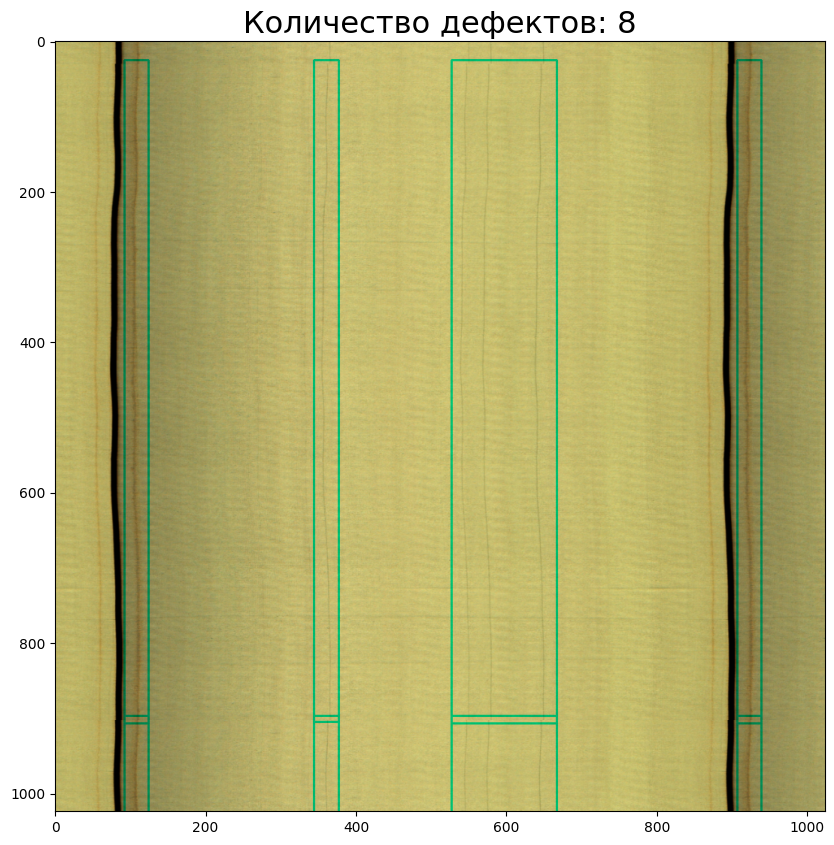

(1024, 1024, 3)
tensor([[361.1456, 465.4868,  23.1131, 870.5266],
        [108.7628, 466.5794,  22.3847, 872.7119],
        [598.2052, 466.5794, 130.7215, 872.7119],
        [923.5211, 466.5794,  22.3847, 872.7119],
        [923.5211, 963.4677,  22.3847, 121.0646],
        [361.1456, 963.4677,  23.1131, 121.0646],
        [108.7628, 963.4677,  22.3847, 121.0646],
        [598.2052, 963.4677, 130.7215, 121.0646]], dtype=torch.float64)


In [68]:
tmp_data = my_dataset[0]
img = tmp_data['img'].permute(1,2,0).numpy()

labes_bbox = yolo_to_opencv_bbox(tmp_data['bboxes'])

tmp_label = np.array(labes_bbox)

# Толщина линии
thickness = 2
color = (0, 0, 255)

# Рисование прямоугольника
for idx in range(tmp_label.shape[0]):
    cv2.rectangle(img[:,:,0], (tmp_label[idx,0]-5, tmp_label[idx,1]-5), (tmp_label[idx,2]+5, tmp_label[idx,3]+5), color, thickness)

# Отображение результата
plt.figure(figsize=(10, 10))
num_defects = tmp_data['bboxes'].shape[0]
plt.title(f'Количество дефектов: {num_defects}', fontsize=22)
plt.imshow(img)
plt.show()
print(img.shape)
print(tmp_data['bboxes'])

# Test crop aug

In [1]:
import numpy as np
import cv2
import random

from ultralytics.utils import IterableSimpleNamespace
from ultralytics.data.dataset import YOLODataset
from ultralytics.data.augment import v8_transforms

import matplotlib.pyplot as plt

INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.5 (you have 1.4.11). Upgrade using: pip install --upgrade albumentations


In [12]:
# create dataset config

default_cfg = IterableSimpleNamespace(task='detect', bgr=0., mode='val', copy_paste_mode='flip', model=None, data=None, epochs=100, patience=50, batch=1, imgsz=1024, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=True, optimizer='auto', verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split='train', save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, line_width=None, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, format='torchscript', keras=False, optimize=False, int8=False, dynamic=False, simplify=False, opset=None, workspace=4, nms=False, lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=7.5, cls=0.5, dfl=1.5, pose=12.0, kobj=1.0, label_smoothing=0.0, nbs=64, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, degrees=0.0, translate=0.1, scale=0.5, shear=0.0, perspective=0.0, flipud=0.0, fliplr=0.5, mosaic=1.0, mixup=0.0, copy_paste=0.0, cfg=None, tracker='botsort.yaml')

In [13]:
my_dataset = YOLODataset(
    data={'names': ['zadir', 'scratch', 'oxidation', 'nakol', 'plena', 'hole', 'omednenie', 'vmyatina', 'rakovina', 'dirt']},
    img_path=r"C:\Users\User\Desktop\Projects\actual\ultralytics_custom_augs\data_test",
    imgsz=1024,
    hyp=default_cfg,
    batch_size=1
)

Scanning C:\Users\User\Desktop\Projects\actual\ultralytics_custom_augs\data_test\labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


In [14]:
def yolo_to_opencv_bbox(yolo_bboxes, image_height, image_width):
    opencv_bboxes = []
    
    for bbox in yolo_bboxes:
        # print(bbox)
        x_center, y_center, width, height = bbox
        
        # Преобразование нормализованных координат в координаты пикселей
        x_center *= image_width
        y_center *= image_height
        width *= image_width
        height *= image_height
        
        # Определение координат верхнего левого угла
        x_min = int(x_center - width / 2)
        y_min = int(y_center - height / 2)
        x_max = int(x_min + width)
        y_max = int(y_min + height)
        opencv_bboxes.append([x_min, y_min, x_max, y_max])
        
    return opencv_bboxes

In [15]:
transforms = v8_transforms(my_dataset, imgsz=640, hyp=default_cfg)
augmented_data = transforms(my_dataset[0])

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))
[[    0.34313     0.49875    0.028368      0.9975]
 [   0.033368         0.5    0.027474           1]
 [    0.63409         0.5     0.16044           1]]
orig img shape (2037, 1900, 3)
transormed img shape (1024, 1024, 3)
[[    0.34313     0.49875    0.028368      0.9975]
 [   0.033368         0.5    0.027474           1]
 [    0.63409         0.5     0.16044           1]]
orig img shape (2037, 1900, 3)
transormed img shape (1024, 1024, 3)
[[    0.34313     0.49875    0.028368      0.9975]
 [   0.033368         0.5    0.027474           1]
 [    0.63409         0.5     0.16044           1]]
orig img shape (2037, 1900, 3)
transormed img shape (1024, 1024, 3)
[[    0.34313     0.49875    0.028368      0.9975]
 [   0.033368         0.5    0.027474           1]
 [    0.63409         0.5     0.16044           1]]
orig img shape (20

KeyError: 'instances'

In [21]:
my_dataset[0]

[[    0.34313     0.49875    0.028368      0.9975]
 [   0.033368         0.5    0.027474           1]
 [    0.63409         0.5     0.16044           1]]
orig img shape (2037, 1900, 3)
transormed img shape (1024, 1024, 3)
[[    0.34313     0.49875    0.028368      0.9975]
 [   0.033368         0.5    0.027474           1]
 [    0.63409         0.5     0.16044           1]]
orig img shape (2037, 1900, 3)
transormed img shape (1024, 1024, 3)
[[    0.34313     0.49875    0.028368      0.9975]
 [   0.033368         0.5    0.027474           1]
 [    0.63409         0.5     0.16044           1]]
orig img shape (2037, 1900, 3)
transormed img shape (1024, 1024, 3)
[[    0.34313     0.49875    0.028368      0.9975]
 [   0.033368         0.5    0.027474           1]
 [    0.63409         0.5     0.16044           1]]
orig img shape (2037, 1900, 3)
transormed img shape (1024, 1024, 3)
[[    0.34313     0.49875    0.028368      0.9975]
 [   0.033368         0.5    0.027474           1]
 [    0.63

{'im_file': 'C:\\Users\\User\\Desktop\\Projects\\actual\\ultralytics_custom_augs\\data_test\\images\\1740054118127_1.jpg',
 'ori_shape': (2037, 1900),
 'resized_shape': (1024, 1024),
 'img': tensor([[[199, 191, 195,  ..., 208, 210, 208],
          [197, 193, 198,  ..., 203, 200, 209],
          [202, 200, 201,  ..., 198, 194, 203],
          ...,
          [201, 199, 201,  ..., 202, 202, 203],
          [206, 202, 203,  ..., 204, 204, 206],
          [207, 203, 201,  ..., 194, 196, 202]],
 
         [[188, 184, 188,  ..., 199, 199, 199],
          [187, 185, 192,  ..., 194, 191, 199],
          [192, 190, 192,  ..., 191, 187, 194],
          ...,
          [193, 191, 193,  ..., 193, 193, 194],
          [199, 195, 195,  ..., 193, 193, 195],
          [199, 196, 194,  ..., 188, 188, 192]],
 
         [[108, 103, 109,  ..., 121, 120, 117],
          [103, 102, 111,  ..., 117, 112, 118],
          [105, 105, 109,  ..., 113, 109, 117],
          ...,
          [110, 108, 110,  ..., 114, 11

transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)
transormed img shape (1024, 1024, 3)


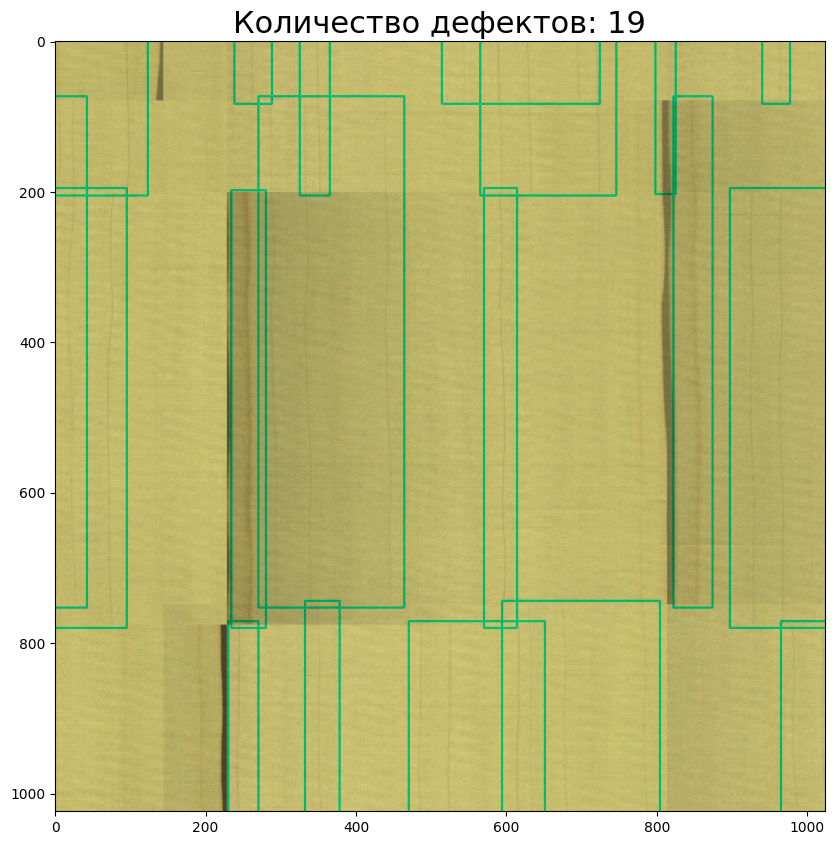

(1024, 1024, 3)
tensor([[367.7353, 413.9101, 184.9640, 670.2166],
        [263.6479,  39.4009,  40.0949,  78.8018],
        [619.3734,  39.4009, 200.2538,  78.8018],
        [959.2925,  39.4009,  27.7771,  78.8018],
        [848.7271, 413.9101,  42.6090, 670.2166],
        [356.0223, 886.5092,  36.9471, 274.9816],
        [699.6617, 886.5092, 200.2268, 274.9816],
        [ 18.9636, 413.9101,  37.9273, 670.2166],
        [592.2369, 488.4474,  34.4164, 575.2997],
        [258.2689, 489.6298,  36.5572, 572.9347],
        [345.8140, 100.3988,  30.2814, 200.7975],
        [656.3963, 100.3988, 171.2639, 200.7975],
        [812.6825,  99.1962,  17.9214, 198.3925],
        [963.1126, 488.4474, 121.7749, 575.2997],
        [997.3887, 900.0486,  53.2226, 247.9028],
        [250.3053, 900.0486,  30.2814, 247.9028],
        [560.8875, 900.0486, 171.2639, 247.9028],
        [ 45.2764, 488.4474,  90.5528, 575.2997],
        [ 59.0828, 100.3988, 118.1656, 200.7975]], dtype=torch.float64)


In [11]:
tmp_data = my_dataset[2]
img = tmp_data['img'].permute(1,2,0).numpy()
h, w = tmp_data['ori_shape']


labes_bbox = yolo_to_opencv_bbox(tmp_data['bboxes'], 1024, 1024)

tmp_label = np.array(labes_bbox)

# Толщина линии
thickness = 2
color = (0, 0, 255)

# Рисование прямоугольника
for idx in range(tmp_label.shape[0]):
    cv2.rectangle(img[:,:,0], (tmp_label[idx,0]-5, tmp_label[idx,1]-5), (tmp_label[idx,2]+5, tmp_label[idx,3]+5), color, thickness)

# Отображение результата
plt.figure(figsize=(10, 10))
num_defects = tmp_data['bboxes'].shape[0]
plt.title(f'Количество дефектов: {num_defects}', fontsize=22)
plt.imshow(img)
plt.show()
print(img.shape)
print(tmp_data['bboxes'])